In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df1 = pd.read_excel(r"../india_weather_rainfall_data.xlsx")
df1

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.0500,74.4000,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.0500,74.4000,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.0500,74.4000,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.0500,74.4000,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.0500,74.4000,25.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970334,2025-02-06,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,27.3,22.0,34.0,7.6,1011.4,5,17.7167,83.2333,0.0
970335,2025-02-07,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.7,23.0,30.0,7.7,1013.1,5,17.7167,83.2333,0.3
970336,2025-02-08,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.7,1013.0,5,17.7167,83.2333,0.0
970337,2025-02-09,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.5,1012.8,5,17.7167,83.2333,0.0


In [26]:
df1.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object')

In [27]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970339 entries, 0 to 970338
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date_of_record  970339 non-null  datetime64[ns]
 1   month           970339 non-null  object        
 2   season          970339 non-null  object        
 3   station_name    970339 non-null  object        
 4   state           970339 non-null  object        
 5   district        970339 non-null  object        
 6   avg_temp        970339 non-null  float64       
 7   min_temp        926441 non-null  float64       
 8   max_temp        859741 non-null  float64       
 9   wind_speed      695895 non-null  float64       
 10  air_pressure    665675 non-null  float64       
 11  elevation       970339 non-null  int64         
 12  latitude        970339 non-null  float64       
 13  longitude       970339 non-null  float64       
 14  rainfall        712785 non-null  flo

In [28]:
numerical = df1.select_dtypes(include=['float64', 'int64']).columns
categorical = df1.select_dtypes(include=['object']).columns
time = df1.select_dtypes(include=['datetime64']).columns
print(numerical, categorical, time)

Index(['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure',
       'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object') Index(['month', 'season', 'station_name', 'state', 'district'], dtype='object') Index(['date_of_record'], dtype='object')


In [29]:
null_count = df1.isnull().sum()
for n, i in enumerate(null_count):
    print(f"{df1.columns[n]} : {i} ({100 - (df1.shape[0] - i)/df1.shape[0]*100:.2f}%)")

date_of_record : 0 (0.00%)
month : 0 (0.00%)
season : 0 (0.00%)
station_name : 0 (0.00%)
state : 0 (0.00%)
district : 0 (0.00%)
avg_temp : 0 (0.00%)
min_temp : 43898 (4.52%)
max_temp : 110598 (11.40%)
wind_speed : 274444 (28.28%)
air_pressure : 304664 (31.40%)
elevation : 0 (0.00%)
latitude : 0 (0.00%)
longitude : 0 (0.00%)
rainfall : 257554 (26.54%)


In [30]:
mask_jh = (
    (df1['state'] == 'JK') &
    (df1['latitude'].between(21, 25)) &
    (df1['longitude'].between(83, 88))
)
print(mask_jh.unique())

df1.loc[mask_jh, 'state'] = 'JH'

[False]


In [31]:
df1['max_temp'] = df1['max_temp'].fillna(df1.groupby(['month', 'station_name'])['max_temp'].transform('mean'))
df1['min_temp'] = df1['min_temp'].fillna(df1.groupby(['month', 'station_name'])['min_temp'].transform('mean'))
df1['wind_speed'] = df1['wind_speed'].fillna(df1.groupby(['month', 'station_name'])['wind_speed'].transform('mean'))
df1['air_pressure'] = df1['air_pressure'].fillna(df1.groupby(['month', 'station_name'])['air_pressure'].transform('mean'))
df1['rainfall'] = df1['rainfall'].fillna(df1.groupby(['month', 'station_name'])['rainfall'].transform('mean'))

In [32]:
df1.isna().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64

In [33]:
df1 = df1.drop_duplicates()
df1.shape

(970339, 15)

In [34]:
df2 = df1.copy()

In [35]:
df2.describe()

,date_of_record,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
count,970339,970339.000000,970339.000000,970339.000000,970339.000000,970339.000000,970339.000000,970339.000000,970339.000000,970339.000000
mean,2021-03-27 08:51:14.557655808,25.661709,20.662863,31.232383,9.433437,1009.335896,298.181018,20.793670,79.426826,4.694407
min,2015-01-01 00:00:00,-10.400000,-18.500000,-5.600000,0.000000,922.600000,0.000000,7.983300,68.850000,0.000000
25%,2019-03-07 00:00:00,23.100000,17.100000,28.600000,6.278862,1005.600000,16.000000,15.850000,75.400000,0.000000
50%,2021-11-09 00:00:00,26.700000,22.400000,31.600000,8.458845,1009.700000,139.000000,21.616700,78.066700,0.500000
75%,2023-06-24 00:00:00,29.100000,25.000000,34.400000,11.562903,1013.200000,436.000000,25.566700,82.716700,4.100000
max,2025-02-10 00:00:00,43.400000,36.600000,87.000000,66.600000,1036.500000,2652.000000,34.083300,95.383300,485.900000
std,NaN,5.438133,5.984740,5.376860,4.687839,5.135678,415.266215,6.328275,5.852512,12.577279


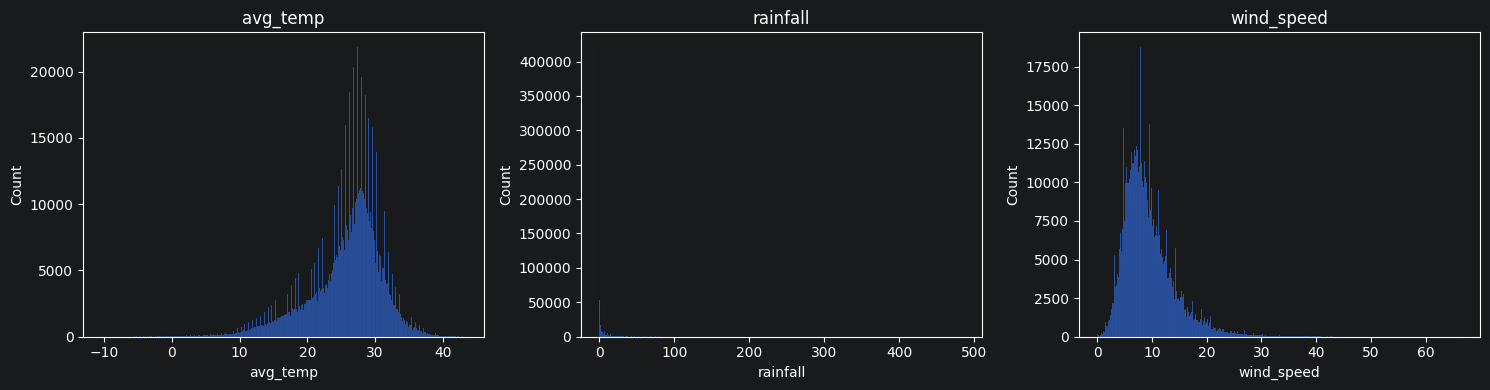

In [37]:
cols = ['avg_temp', 'rainfall', 'wind_speed']
fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

for i, col in enumerate(cols):
    sns.histplot(df2[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

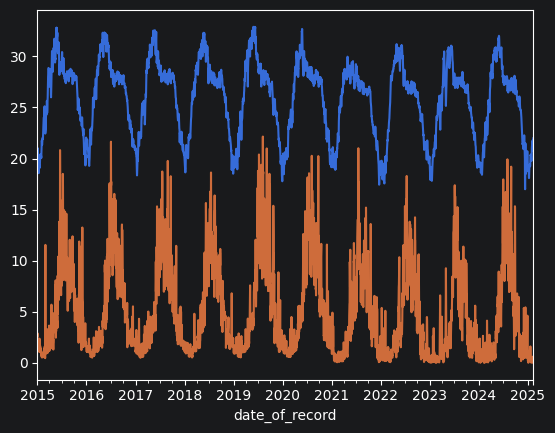

In [38]:
df2.groupby('date_of_record')['avg_temp'].mean().plot()
df2.groupby('date_of_record')['rainfall'].mean().plot()
plt.show()

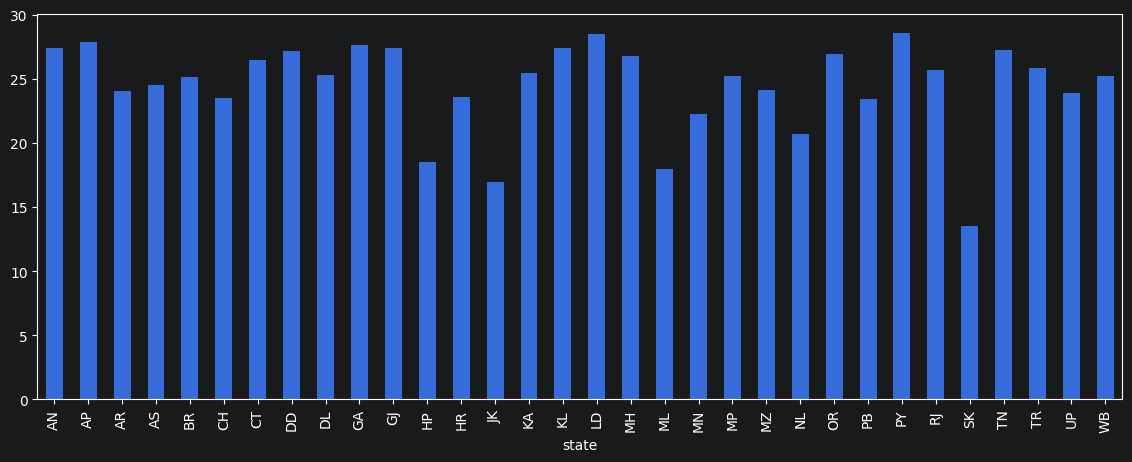

In [73]:
df2.groupby('state')['avg_temp'].mean().plot(kind='bar', figsize=(14,5))
plt.xticks(rotation=90)
plt.show()

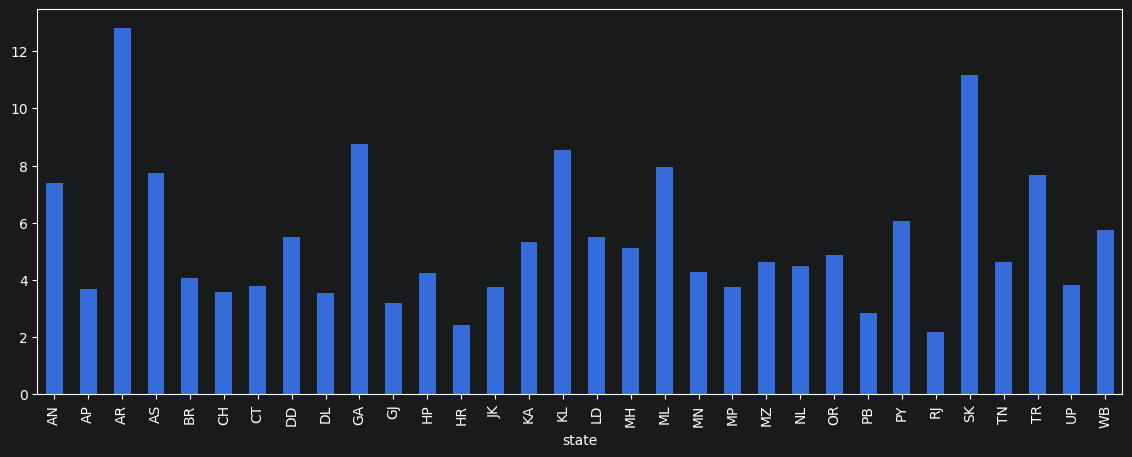

In [74]:
df2.groupby('state')['rainfall'].mean().plot(kind='bar', figsize=(14,5))
plt.xticks(rotation=90)
plt.show()

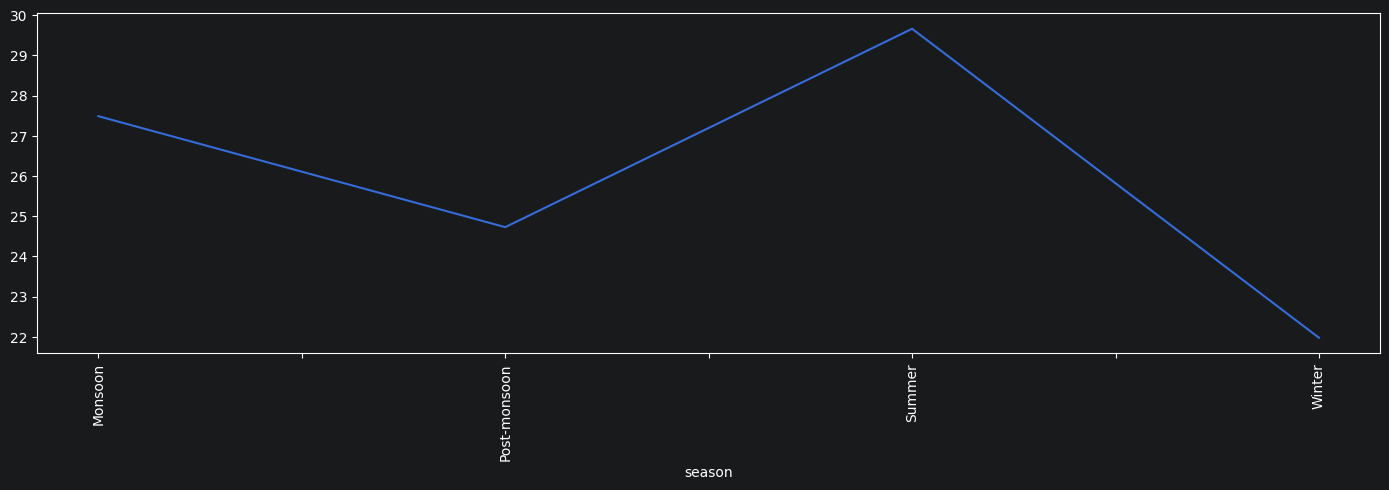

In [45]:
df2.groupby('season')['avg_temp'].mean().plot(figsize=(14,5))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

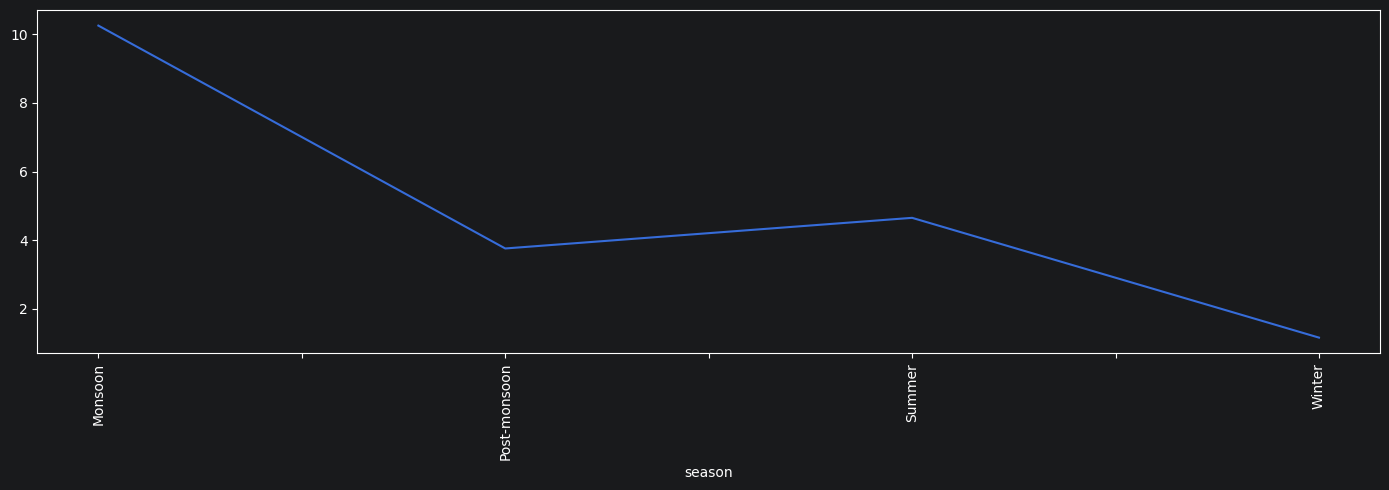

In [46]:
df2.groupby('season')['rainfall'].mean().plot(figsize=(14,5))
plt.xticks(rotation=90)
plt.show()

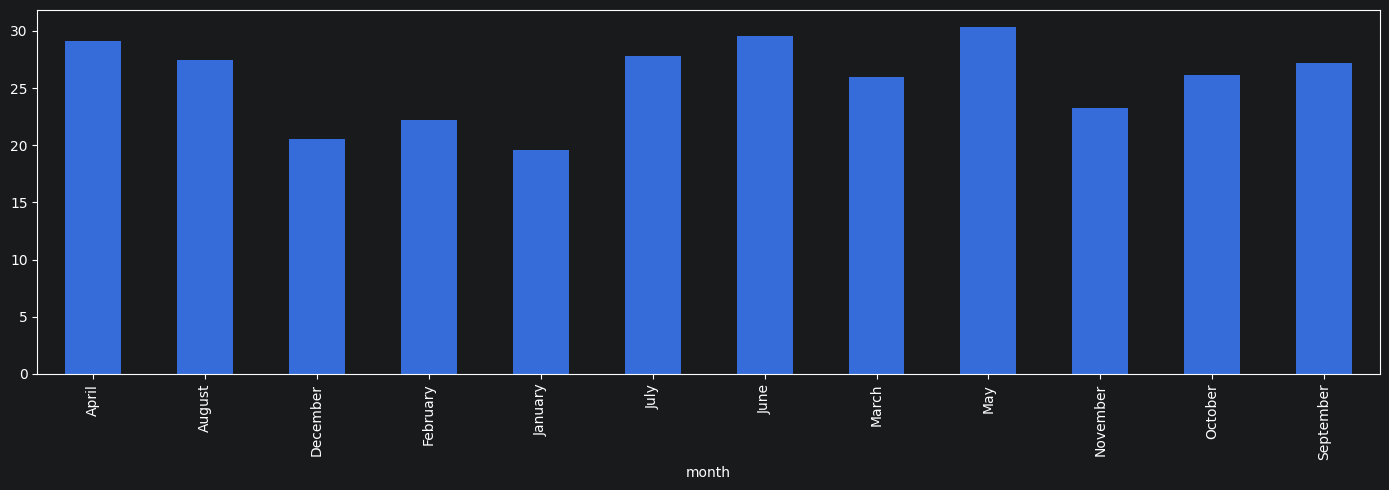

In [50]:
df2.groupby('month')['avg_temp'].mean().plot(kind='bar', figsize=(14,5))
plt.xticks(rotation=90)
plt.show()

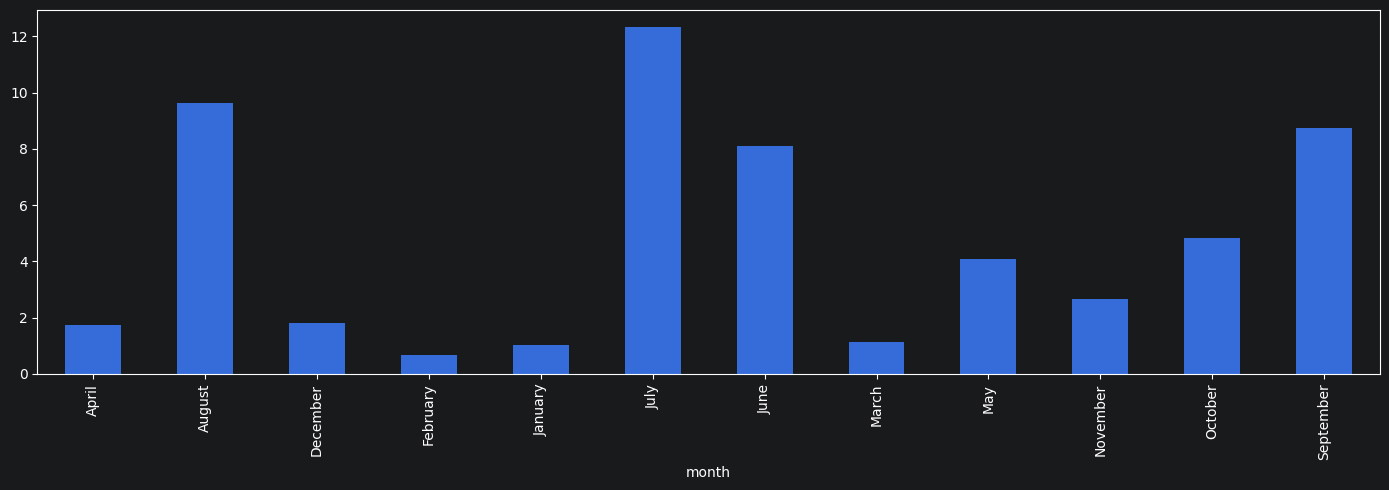

In [49]:
df2.groupby('month')['rainfall'].mean().plot(kind='bar', figsize=(14,5))
plt.xticks(rotation=90)
plt.show()

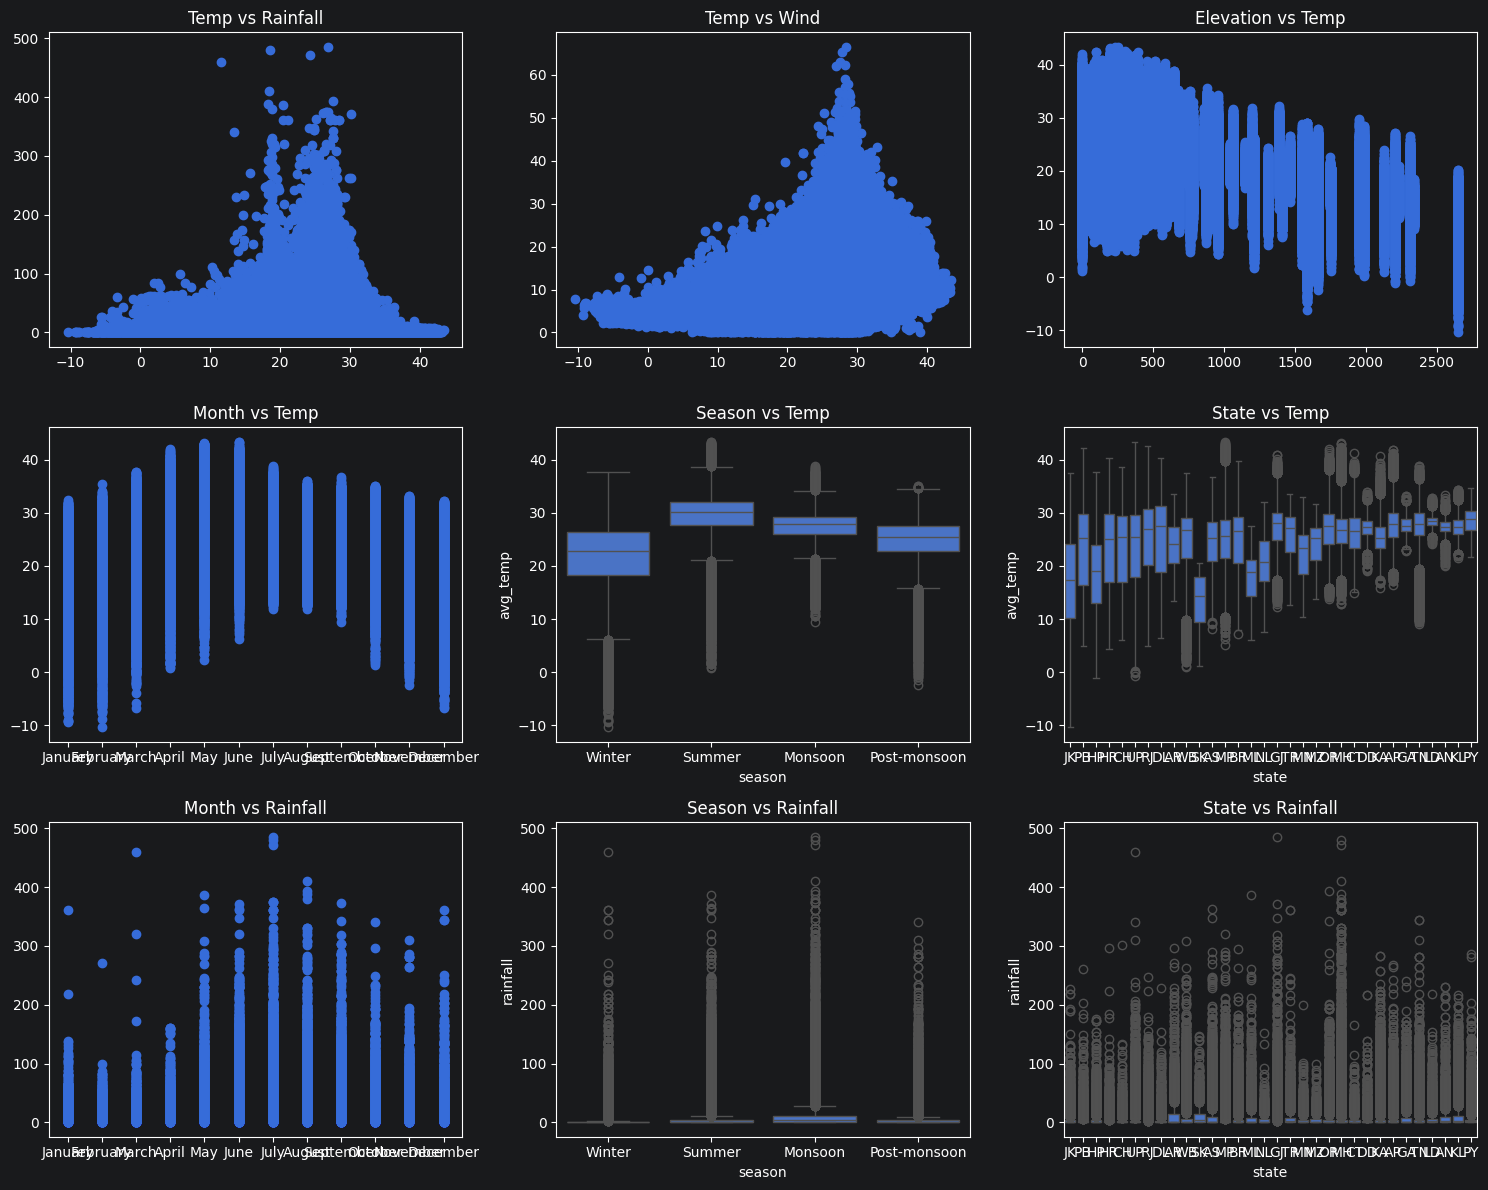

In [60]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes[0, 0].scatter(df2['avg_temp'], df2['rainfall'])
axes[0, 0].set_title("Temp vs Rainfall")

axes[0, 1].scatter(df2['avg_temp'], df2['wind_speed'])
axes[0, 1].set_title("Temp vs Wind")

axes[0, 2].scatter(df2['elevation'], df2['avg_temp'])
axes[0, 2].set_title("Elevation vs Temp")

axes[1, 0].scatter(df2['month'], df2['avg_temp'])
axes[1, 0].set_title("Month vs Temp")

axes[2, 0].scatter(df2['month'], df2['rainfall'])
axes[2, 0].set_title("Month vs Rainfall")

sns.boxplot(x='season', y='avg_temp', data=df2, ax=axes[1, 1])
axes[1, 1].set_title("Season vs Temp")

sns.boxplot(x='state', y='avg_temp', data=df2, ax=axes[1, 2])
axes[1, 2].set_title("State vs Temp")

sns.boxplot(x='season', y='rainfall', data=df2, ax=axes[2, 1])
axes[2, 1].set_title("Season vs Rainfall")

sns.boxplot(x='state', y='rainfall', data=df2, ax=axes[2, 2])
axes[2, 2].set_title("State vs Rainfall")

plt.tight_layout()
plt.show()

<Axes: >

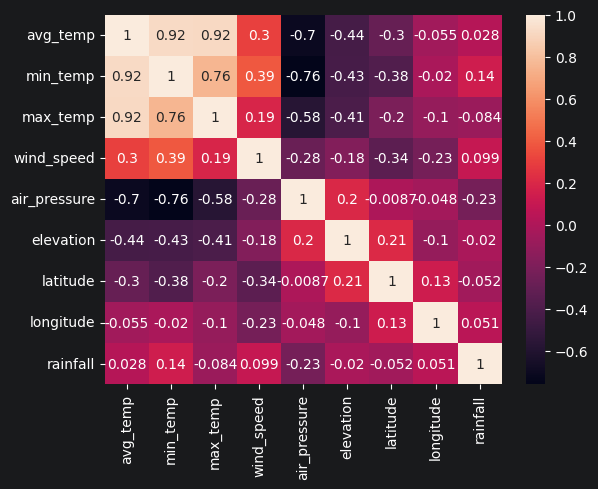

In [62]:
df2.corr(numeric_only=True)
sns.heatmap(df2.corr(numeric_only=True), annot=True)

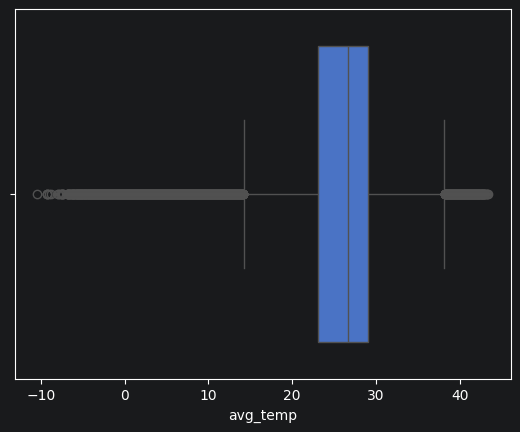

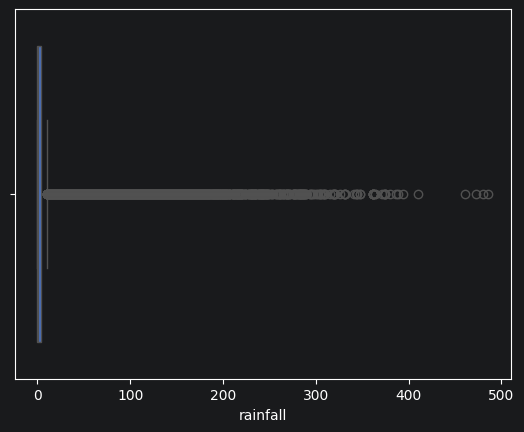

In [64]:
sns.boxplot(x=df2['avg_temp'])
plt.show()
sns.boxplot(x=df2['rainfall'])
plt.show()

In [75]:
Q1 = df1['rainfall'].quantile(0.25)
Q3 = df1['rainfall'].quantile(0.75)
IQR = Q3 - Q1

outliers = df1[(df1['rainfall'] < Q1 - 1.5*IQR) | (df1['rainfall'] > Q3 + 1.5*IQR)]
print("Rainfall outliers:", outliers.shape[0])

Rainfall outliers: 118388


In [76]:
Q1 = df1['avg_temp'].quantile(0.25)
Q3 = df1['avg_temp'].quantile(0.75)
IQR = Q3 - Q1

outliers = df1[(df1['avg_temp'] < Q1 - 1.5*IQR) | (df1['avg_temp'] > Q3 + 1.5*IQR)]
print("Avg Temp outliers:", outliers.shape[0])

Avg Temp outliers: 41011


In [69]:
df2.corr(numeric_only=True)['avg_temp'].sort_values()

air_pressure   -0.703504
elevation      -0.439126
latitude       -0.296831
longitude      -0.054895
rainfall        0.028063
wind_speed      0.300535
max_temp        0.916885
min_temp        0.917605
avg_temp        1.000000
Name: avg_temp, dtype: float64

In [68]:
df2.corr(numeric_only=True)['rainfall'].sort_values()

air_pressure   -0.234767
max_temp       -0.083699
latitude       -0.052171
elevation      -0.020198
avg_temp        0.028063
longitude       0.050741
wind_speed      0.098604
min_temp        0.137705
rainfall        1.000000
Name: rainfall, dtype: float64

In [72]:
df2.describe().to_json("summary.json")